<h1 align="center">0. Imports and Configurations</h1>

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data

module_dir = Path.cwd()
if not (module_dir / "models.py").exists():
    candidate_dir = module_dir / "code"
    if (candidate_dir / "models.py").exists():
        module_dir = candidate_dir

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from models import GNN, MLP
import networkx as nx
import random
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.neighbors import kneighbors_graph
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold, RepeatedKFold, RepeatedStratifiedKFold, train_test_split
import torch_geometric.utils
from typing import Literal, Dict, List, Tuple
from sklearn.metrics import accuracy_score, silhouette_score
import utils
from sklearn.feature_selection import SelectKBest, f_classif
from torch_geometric.utils import to_undirected, to_networkx
from joblib import Parallel, delayed
import itertools
from collections import defaultdict
import scipy.stats as st
from torch_geometric.utils import homophily
import math
import copy




%matplotlib inline
warnings.filterwarnings('ignore')


def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set at {seed}.")

set_seed(42)

Seed set at 42.


<h1 align="center">1. Dataset Loading  </h1>

In [ ]:
df = pd.read_csv("dataset/dataset_LUMINAL_A_B.csv")
# target column cleaning
if 'l' in df.columns:
    df['l'] = df['l'].astype(str).str.strip()

<h1 align="center">2. Dataframe Exploration</h1>

<h2 align="center">2.1 Dataset Structure & Metadata</h2>

In [3]:
print(f"Dataset Shape: {df.shape[0]} Samples (Rows) x {df.shape[1]} Columns")
print("-" * 40)

print("Data Types Summary:")
print(df.dtypes.value_counts())

Dataset Shape: 100 Samples (Rows) x 1023 Columns
----------------------------------------
Data Types Summary:
float64    938
int64       84
object       1
Name: count, dtype: int64


<h2 align="center">2.2 Data Integrity & Global Statistics</h2>

In [4]:
print("Integrity Check:")
print(f"Missing values: {df.isnull().sum().sum()}")

duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
print("-" * 40)

# we temporarily work without the target columns
numeric_df = df.drop(columns=['l'])

total_cells = numeric_df.size
total_zeros = (numeric_df == 0).sum().sum()
sparsity_pct = (total_zeros / total_cells) * 100
print(f"Global Statistics:")
print(f"Total Cells: {total_cells:,}")
print(f"Total Zeros: {total_zeros:,}")
print(f"Global Sparsity: {sparsity_pct:.2f}%")
print("-" * 40)

global_min = numeric_df.min().min()
global_max = numeric_df.max().max()
print(f"Min Value: {global_min:,.2f}")
print(f"Max Value: {global_max:,.2f}")
print("-" * 40)

silent_genes = (numeric_df == 0).all(axis=0).sum()
print(f"Genes with zero expression in all samples (silent genes): {silent_genes}")


Integrity Check:
Missing values: 0
Duplicate Rows: 0
----------------------------------------
Global Statistics:
Total Cells: 102,200
Total Zeros: 47,513
Global Sparsity: 46.49%
----------------------------------------
Min Value: 0.00
Max Value: 3,214,496,710.67
----------------------------------------
Genes with zero expression in all samples (silent genes): 84


<h2 align="center">2.3 Sample Quality Check (Library Sizes)</h2>

Lib size min: 83,080,847.21
Lib size max: 3,723,676,510.92
Lib size avg: 217,901,779.66
----------------------------------------


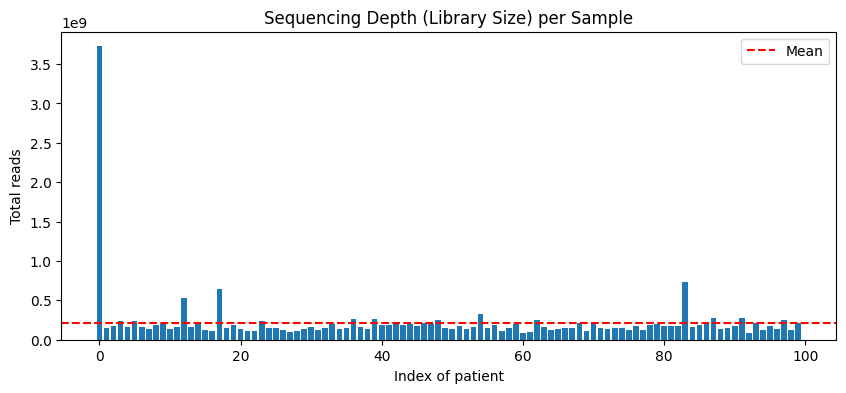

In [5]:
numeric_df = df.drop(columns=['l'])
lib_size = numeric_df.sum(axis=1)
print(f"Lib size min: {lib_size.min():,.2f}\nLib size max: {lib_size.max():,.2f}\nLib size avg: {lib_size.mean():,.2f}")
print("-" * 40)

plt.figure(figsize=(10, 4))
plt.bar(lib_size.index, lib_size.values)
plt.axhline(y=lib_size.mean(), color='r', linestyle='--', label='Mean')
plt.title("Sequencing Depth (Library Size) per Sample")
plt.xlabel("Index of patient")
plt.ylabel("Total reads")
plt.legend()
plt.show()


<h2 align="center">2.4 Feature Analysis (Top Genes & Variance)</h2>

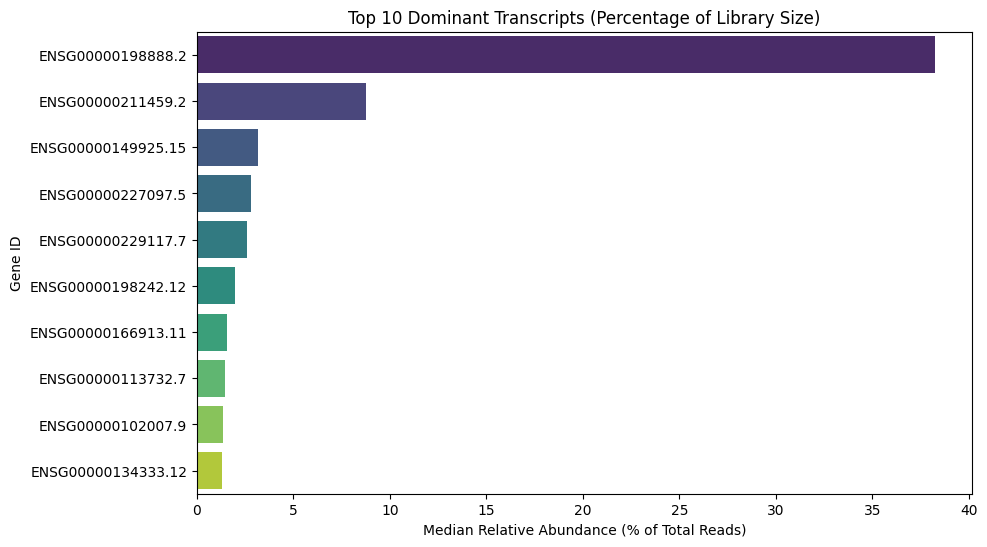

In [6]:
#i calculated the total number of reads for each patient (axis = 1)
library_sizes = numeric_df.sum(axis=1)
#i divided each element by the total number of reads, so that each row sums to 100
relative_abundance_df = numeric_df.div(library_sizes, axis=0) * 100

#this tells me the genes that are the most expressed in most (median) patients
top_genes_pct = relative_abundance_df.median().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genes_pct.values, y=top_genes_pct.index, palette='viridis')

plt.xlabel("Median Relative Abundance (% of Total Reads)") 
plt.title("Top 10 Dominant Transcripts (Percentage of Library Size)")
plt.ylabel("Gene ID")
plt.show()


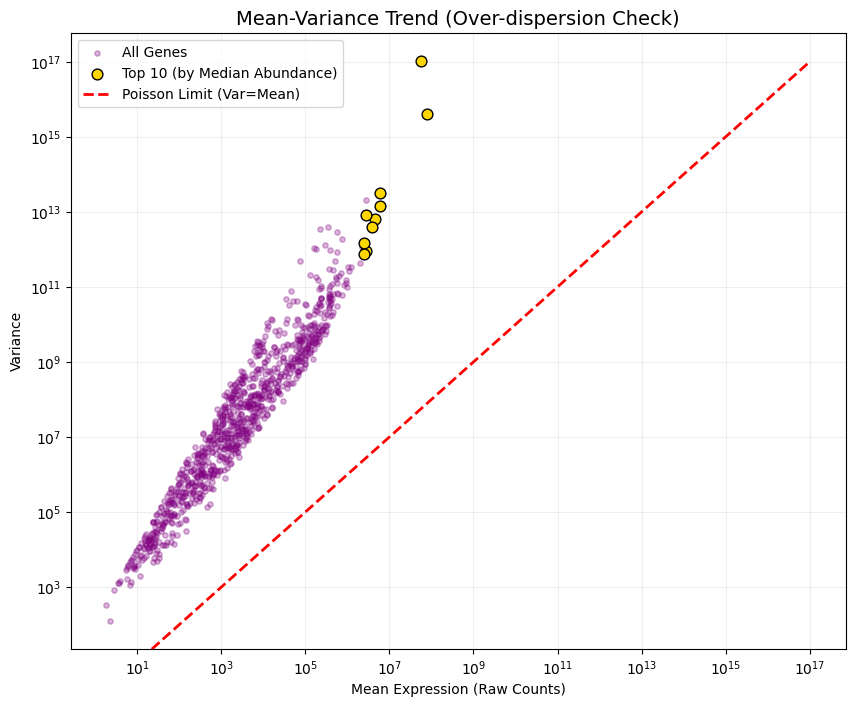

In [7]:
gene_means = numeric_df.mean(axis=0)
gene_vars = numeric_df.var(axis=0)

#i calculated the top ten genes that are in absolute the most expressed 
top_10_names = numeric_df.median().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
plt.scatter(gene_means, gene_vars, alpha=0.3, s=15, color='purple', label='All Genes')
plt.scatter(gene_means[top_10_names], gene_vars[top_10_names], 
            color='gold', s=60, edgecolor='black', zorder=5, label='Top 10 (by Median Abundance)')
#Logarithmic scales to see the data
plt.xscale('log')
plt.yscale('log')
plt.title("Mean-Variance Trend (Over-dispersion Check)", fontsize=14)
plt.xlabel("Mean Expression (Raw Counts)") # Corretto da CPM a Raw Counts
plt.ylabel("Variance")

# Poisson line: min = var
min_val = min(gene_means.min(), gene_vars.min())
max_val = max(gene_means.max(), gene_vars.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Poisson Limit (Var=Mean)")
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()

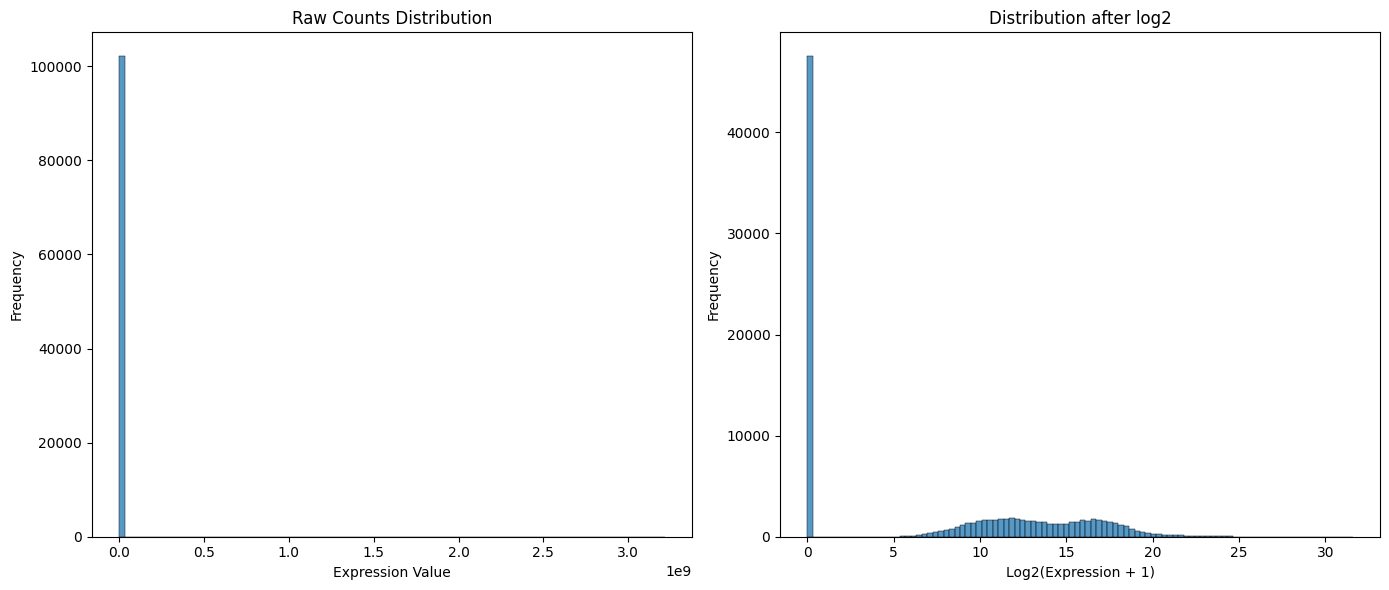

In [8]:
#Analysis of the distribution
#this step serves to "unroll" all the values so i can compute a histogram on them
all_data = numeric_df.values.flatten() 

plt.figure(figsize=(14, 6))

# Left: Original distribution
plt.subplot(1, 2, 1)
sns.histplot(all_data, bins=100)
plt.title(f"Raw Counts Distribution")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")

# Right: transformed distribution with logarithm
df_log = np.log2(numeric_df + 1)
all_data_log = df_log.values.flatten()
plt.subplot(1, 2, 2)
sns.histplot(all_data_log, bins=100)
plt.title("Distribution after log2")
plt.xlabel("Log2(Expression + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


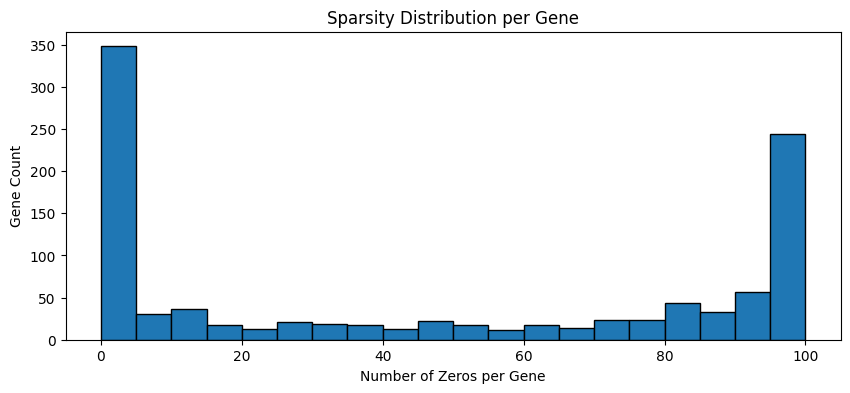

In [9]:
# Sparsity distribution
#this graph counts the number of genes (y column) that are "off" in N (X axis) patients
zeros_per_gene = (df_log == 0).sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(zeros_per_gene, bins=20, edgecolor='black')
plt.xlabel("Number of Zeros per Gene")
plt.ylabel("Gene Count")
plt.title("Sparsity Distribution per Gene")
plt.show()

In [10]:
p = 0.05 
min_n = int(np.ceil(p * numeric_df.shape[0]))

mask = df_log.gt(0).sum(axis=0) >= min_n
filtered_df = df_log.loc[:, mask]

print(f"kept genes: {filtered_df.shape[1]}")

#this operation only keeps the genes that are on in more than 5 patients

kept genes: 793


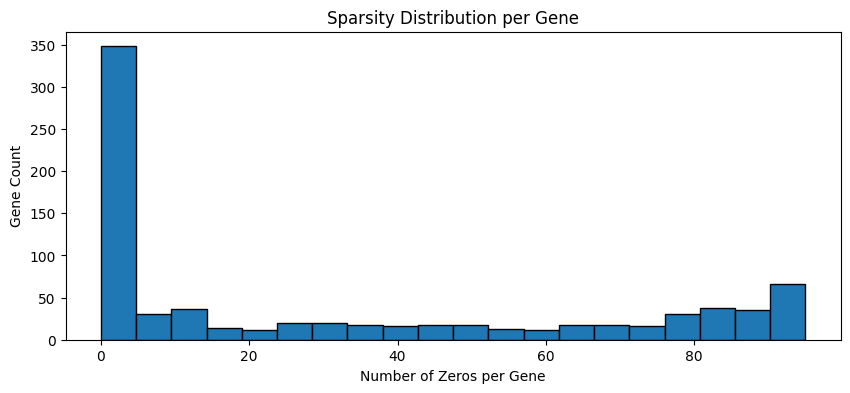

In [11]:
#sparsity distribution after genes removal
#this plot simply shows that i removed the second high bar at the right extremity
zeros_per_gene = (filtered_df == 0).sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(zeros_per_gene, bins=20, edgecolor='black')
plt.xlabel("Number of Zeros per Gene")
plt.ylabel("Gene Count")
plt.title("Sparsity Distribution per Gene")
plt.show()

<h2 align="center">2.5 Class Balance (Target Analysis)</h2>

In [12]:
y = df["l"].copy()

class_counts = y.value_counts()
print("Class distribution")
print(class_counts)
#just to confirm the data is balanced or not

Class distribution
l
Luminal A    50
Luminal B    50
Name: count, dtype: int64


<h2 align="center">2.6 PCA Analysis </h2>

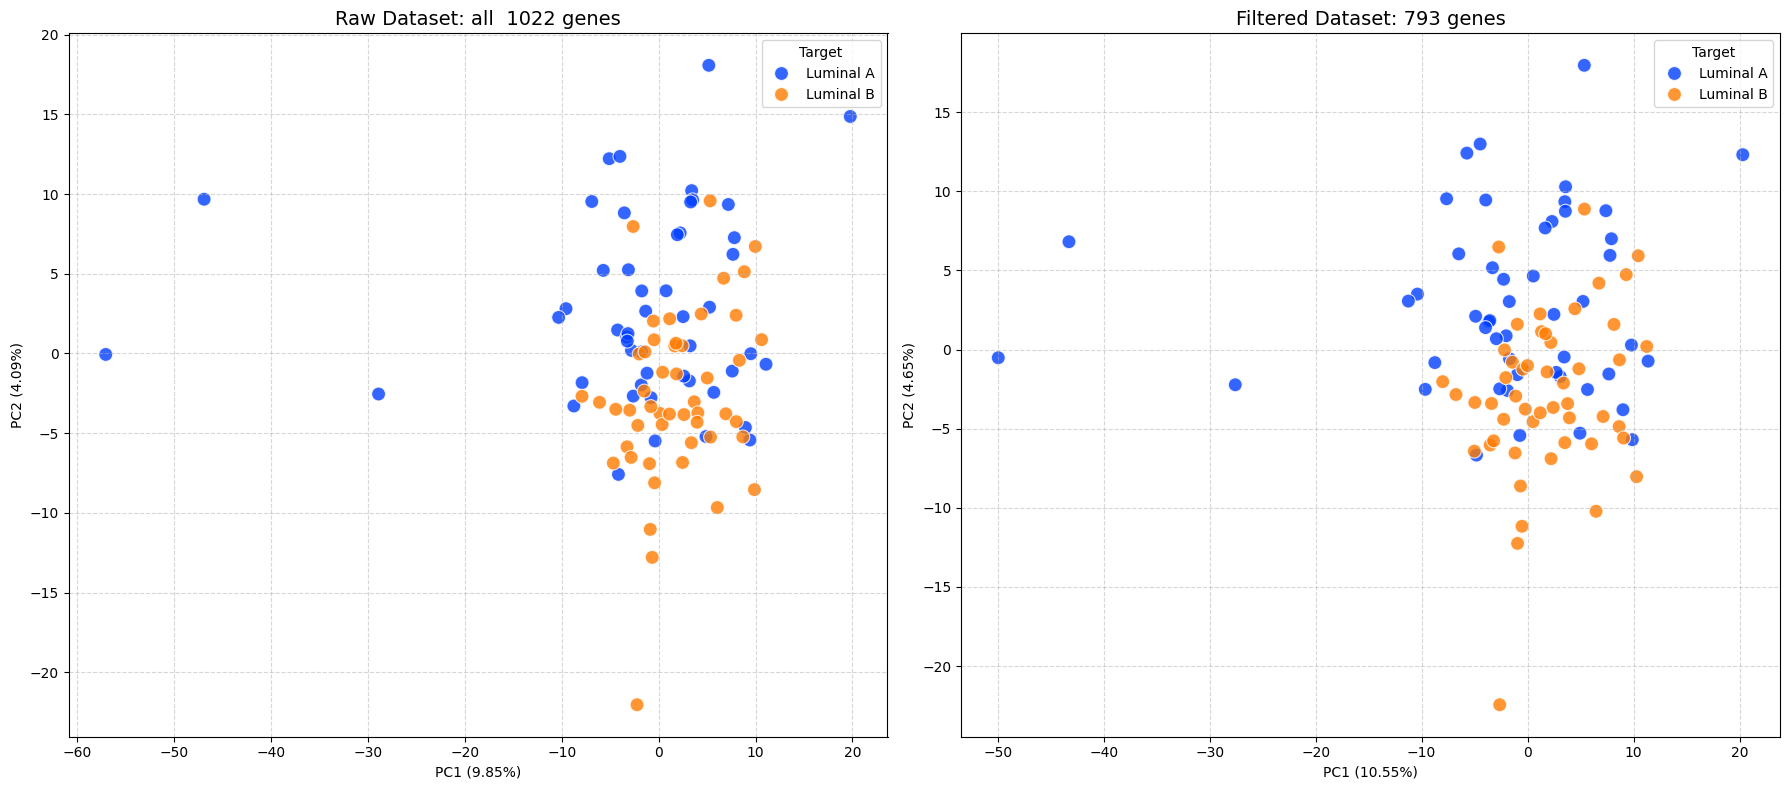

In [13]:
#PCA on df_log.
scaler_raw = StandardScaler()
X_scaled_raw = scaler_raw.fit_transform(df_log)

pca_raw = PCA(n_components=2, random_state=42)
coords_raw = pca_raw.fit_transform(X_scaled_raw)
var_raw = pca_raw.explained_variance_ratio_ * 100

pca_df_raw = pd.DataFrame(data=coords_raw, columns=['PC1', 'PC2'])
pca_df_raw['Target'] = df['l']


#PCA on filtered_df
scaler_filt = StandardScaler()
X_scaled_filt = scaler_filt.fit_transform(filtered_df)

pca_filt = PCA(n_components=2, random_state=42)
coords_filt = pca_filt.fit_transform(X_scaled_filt)
var_filt = pca_filt.explained_variance_ratio_ * 100

pca_df_filt = pd.DataFrame(data=coords_filt, columns=['PC1', 'PC2'])
pca_df_filt['Target'] = df['l']


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot A
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df_raw, 
                palette='bright', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title(f"Raw Dataset: all  {df_log.shape[1]} genes", fontsize=14)
axes[0].set_xlabel(f"PC1 ({var_raw[0]:.2f}%)")
axes[0].set_ylabel(f"PC2 ({var_raw[1]:.2f}%)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot B
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df_filt, 
                palette='bright', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title(f"Filtered Dataset: {filtered_df.shape[1]} genes", fontsize=14)
axes[1].set_xlabel(f"PC1 ({var_filt[0]:.2f}%)")
axes[1].set_ylabel(f"PC2 ({var_filt[1]:.2f}%)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#comparing the 2 plots shows that removing these silent genes didn't influence the data but allowed for less parameters, which means easier models

<h2 align="center">2.7 Exploratory Correlation Analysis </h2>

Minimum Correlation found: 0.4122


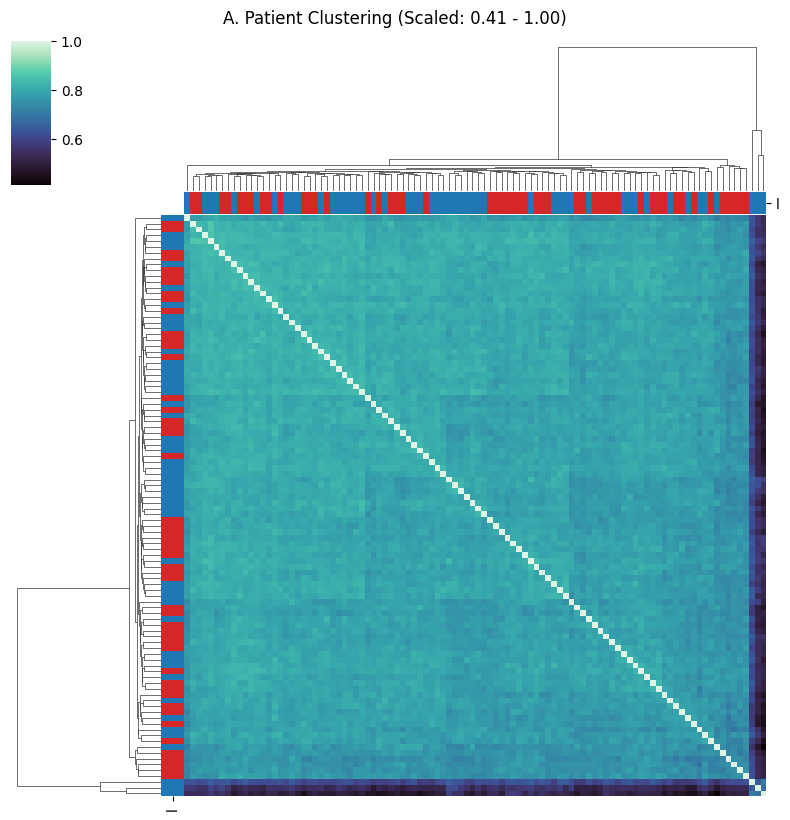

In [14]:
patient_corr = filtered_df.T.corr(method='pearson')

min_corr = patient_corr.min().min()
print(f"Minimum Correlation found: {min_corr:.4f}")

sample_colors = df['l'].map({'Luminal A': '#1f77b4', 'Luminal B': '#d62728'})

g = sns.clustermap(patient_corr,
                   row_colors=sample_colors,
                   col_colors=sample_colors,
                   cmap='mako',
                   #i scaled the colors
                   vmin=min_corr, vmax=1.0,  
                   figsize=(8, 8),
                   xticklabels=False, yticklabels=False)

g.figure.suptitle(f"A. Patient Clustering (Scaled: {min_corr:.2f} - 1.00)", y=1.02)
plt.show()
#this plot was done to see if there were island of patients, meaning all Luminal A (or a relevant subsection) were similar to each other and different from the luminal B's

<h1 align="center">3. Graph Construction </h1>

In [ ]:
#reloading dataset and re-applying all transformations. this is done so there is no need to execute all the previous steps

df = pd.read_csv("dataset/dataset_LUMINAL_A_B.csv")
target_col = 'l'
df[target_col] = df[target_col].astype(str).str.strip()
df[target_col] = df[target_col].map({'Luminal B': 0, 'Luminal A': 1})

y = df[target_col].copy()
numeric_df = df.drop(columns=[target_col]).copy()

p = 0.05
min_n = int(np.ceil(p * numeric_df.shape[0]))

df_log = np.log2(numeric_df + 1)
mask = df_log.gt(0).sum(axis=0) >= min_n

filtered_df = df_log.loc[:, mask].copy()

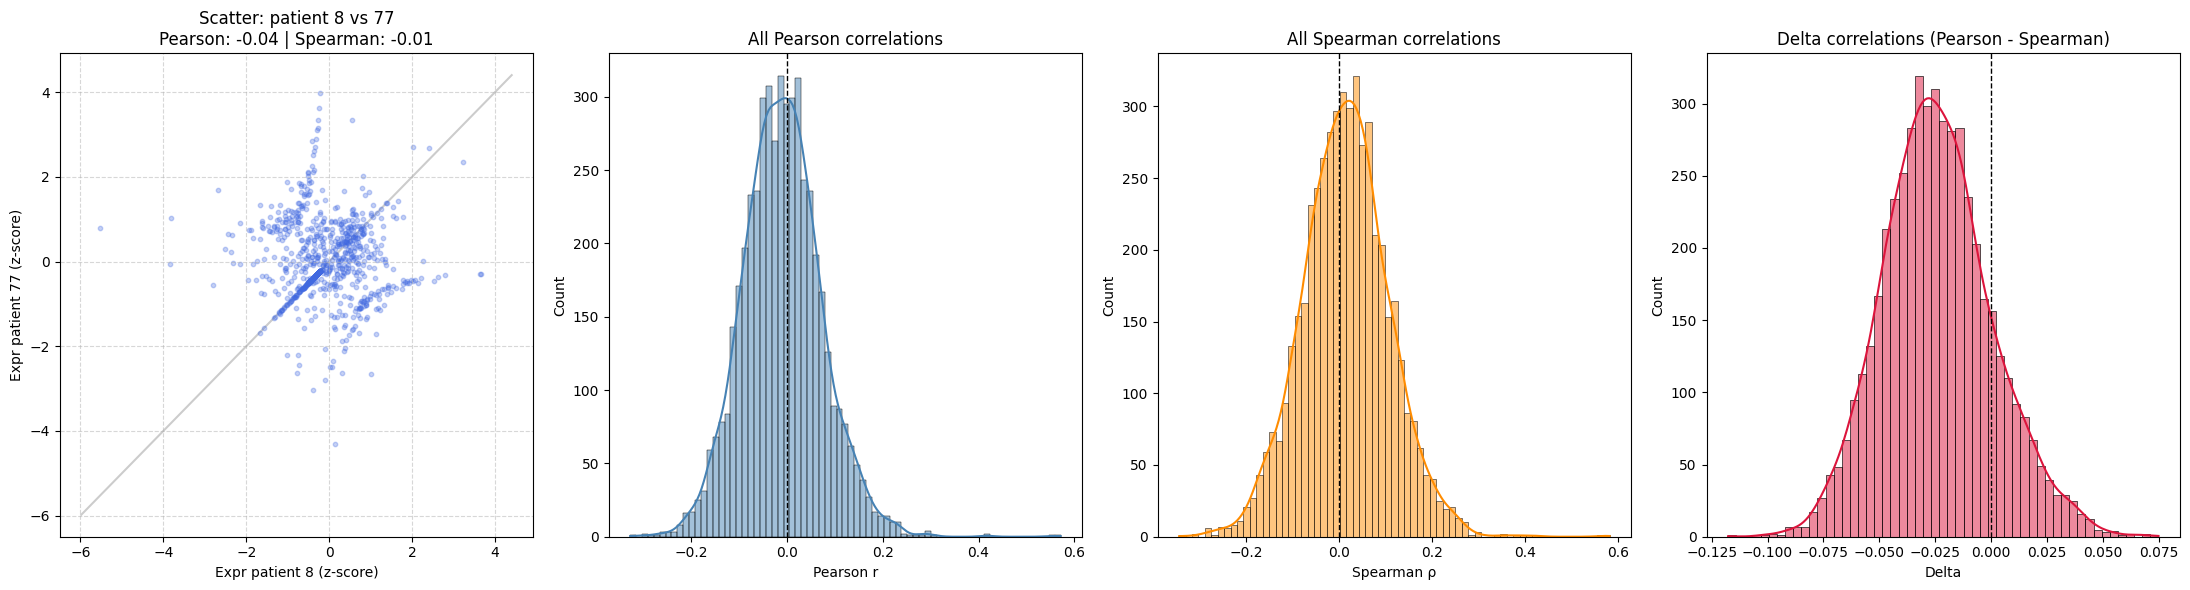

In [16]:
#Standardize gene-wise (z-score per gene)
X = filtered_df.copy()
X = (X - X.mean(axis=0)) / X.std(axis=0).replace(0, 1)

#correlation matrices (patient-patient)
corr_pearson  = X.T.corr(method="pearson")
corr_spearman = X.T.corr(method="spearman")

#Pick 2 random patients + scatter
n = len(X)
rng = np.random.default_rng(42)
i, j = rng.choice(n, size=2, replace=False)

p1 = X.iloc[i, :]
p2 = X.iloc[j, :]

p_ij = corr_pearson.iloc[i, j]
s_ij = corr_spearman.iloc[i, j]

#Extract all unique pair correlations
idx = np.triu_indices(n, k=1)
pearson_vals  = corr_pearson.to_numpy()[idx]
spearman_vals = corr_spearman.to_numpy()[idx]
delta_vals    = pearson_vals - spearman_vals

#Plot: scatter + hist Pearson + hist Spearman + hist Delta
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# Scatter
axes[0].scatter(p1, p2, alpha=0.3, s=10, c="royalblue")
axes[0].set_title(f"Scatter: patient {i} vs {j}\nPearson: {p_ij:.2f} | Spearman: {s_ij:.2f}")
axes[0].set_xlabel(f"Expr patient {i} (z-score)")
axes[0].set_ylabel(f"Expr patient {j} (z-score)")
axes[0].grid(True, linestyle="--", alpha=0.5)

lims = [
    min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]),
    max(axes[0].get_xlim()[1], axes[0].get_ylim()[1]),
]
axes[0].plot(lims, lims, "k-", alpha=0.2, zorder=0)

# Pearson histogram
sns.histplot(pearson_vals, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("All Pearson correlations")
axes[1].set_xlabel("Pearson r")

# Spearman histogram
sns.histplot(spearman_vals, kde=True, ax=axes[2], color="darkorange")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("All Spearman correlations")
axes[2].set_xlabel("Spearman ρ")

# Delta histogram
sns.histplot(delta_vals, kde=True, ax=axes[3], color="crimson")
axes[3].axvline(0, color="black", linestyle="--", linewidth=1)
axes[3].set_title("Delta correlations (Pearson - Spearman)")
axes[3].set_xlabel("Delta")

plt.tight_layout()
plt.show()

#these plots show that now the data are not all similar to each other and that Pearson / Spearman Correlations are very similar

In [17]:
corr_matrix = X.T.corr(method="pearson")
np.fill_diagonal(corr_matrix.values, 0)

min_corr = corr_matrix.min().min()
max_corr = corr_matrix.max().max()

np.fill_diagonal(corr_matrix.values, -np.inf)

#i test 50 different thresholds from the minimum to (almost) the maximum
thresholds = np.linspace(min_corr, max_corr * 0.99, 50)

results = []

print(f"Analysis of {len(thresholds)} thresholds (from {thresholds[0]:.2f} to {thresholds[-1]:.2f})")

for t in thresholds:
    #i build an undirected, non-weighted graph using  the given correlation threshold
    adj_bool = corr_matrix > t
    G = nx.from_pandas_adjacency(adj_bool) 
    
    # METRICS

    #metric 1: total number of edges of the graph
    num_edges = G.number_of_edges()
    
    #metric 2: average degree of the graph: average number of neighbors each node has
    avg_degree = np.mean([d for n, d in G.degree()])
    
    #metric 3: average clustering coefficient = fraction of neighbor pairs that are connected
    avg_clustering = nx.average_clustering(G)
    
    #metric 4, 5, 6: 
    #   average shortest path length in Largest Connected Component (LCC)
    #   total number of connected components in full graph
    #   % nodes in Largest Connected Component (giant component fraction) 
    if num_edges > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        nodes_in_lcc = len(subgraph)
        
        avg_path_len = nx.average_shortest_path_length(subgraph) if len(subgraph) > 1 else 0
        
        n_components = nx.number_connected_components(G)
    else:
        avg_path_len = 0
        n_components = len(G.nodes)
        nodes_in_lcc = 0

    results.append({
        'Threshold': t,
        'Edges': num_edges, 
        'Avg_Degree': avg_degree, 
        'Avg_Clustering': avg_clustering,
        'Avg_Path_Length': avg_path_len,
        'Connected_Components': n_components,
        'Nodes_in_LCC_pct': nodes_in_lcc / len(G.nodes) * 100
    })

df_res = pd.DataFrame(results)

Analysis of 50 thresholds (from -0.33 to 0.57)


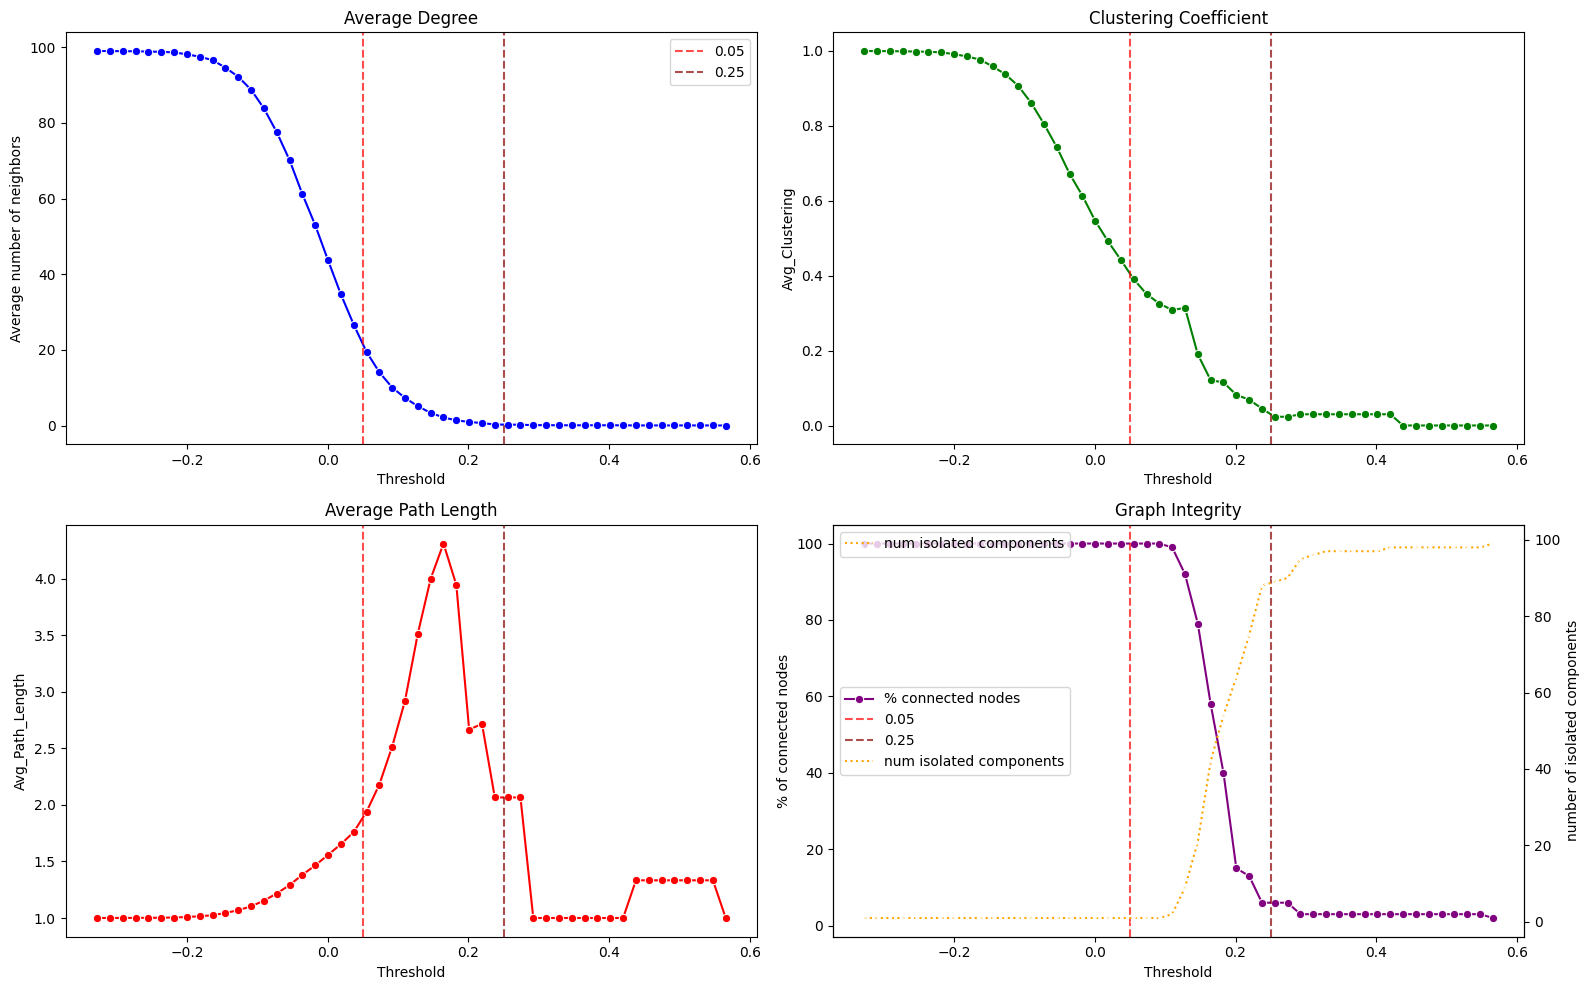

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# this function adds 2 vertical markers at the thresholds 0.05 - 0.25
def add_markers(ax):
    ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='0.05')
    ax.axvline(0.25, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7, label='0.25')

#Plot 1: average degree 
sns.lineplot(data=df_res, x='Threshold', y='Avg_Degree', ax=axes[0,0], marker='o', color='blue')
axes[0,0].set_title("Average Degree")
axes[0,0].set_ylabel("Average number of neighbors")
add_markers(axes[0,0])
axes[0,0].legend()

# Plot 2: Clustering
sns.lineplot(data=df_res, x='Threshold', y='Avg_Clustering', ax=axes[0,1], marker='o', color='green')
axes[0,1].set_title("Clustering Coefficient")
add_markers(axes[0,1])

# Plot 3: Path Length
sns.lineplot(data=df_res, x='Threshold', y='Avg_Path_Length', ax=axes[1,0], marker='o', color='red')
axes[1,0].set_title("Average Path Length")
add_markers(axes[1,0])

# Plot 4: Frammentazione
ax4 = axes[1,1]
sns.lineplot(data=df_res, x='Threshold', y='Nodes_in_LCC_pct', ax=ax4, marker='o', color='purple', label='% connected nodes')
ax4.set_title("Graph Integrity")
ax4.set_ylabel("% of connected nodes")
add_markers(ax4)

# Plot 4, second axis
ax4b = ax4.twinx()
sns.lineplot(data=df_res, x='Threshold', y='Connected_Components', ax=ax4b, marker='x', color='orange', linestyle=':', label='num isolated components')
ax4b.set_ylabel("number of isolated components")

lines, labels = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines + lines2, labels + labels2, loc='center left')

plt.tight_layout()
plt.show()

In [19]:
#ZOOM IN: range 0.05 - 0.25, 100 steps
#same code as before we just repeat the analysis on this new range
thresholds = np.linspace(0.05, 0.25, 100)
results = []

print(f"Zoom analysis: {len(thresholds)} thresholds (from {thresholds[0]:.4f} to {thresholds[-1]:.4f})...")

for t in thresholds:
    
    adj_bool = corr_matrix > t
    G = nx.from_pandas_adjacency(adj_bool)
    
    num_edges = G.number_of_edges()
    
    avg_degree = np.mean([d for n, d in G.degree()])
        
    avg_clustering = nx.average_clustering(G)
    
    if num_edges > 0:
        components = list(nx.connected_components(G))
        largest_cc = max(components, key=len)
        subgraph = G.subgraph(largest_cc)
        
        nodes_in_lcc = len(subgraph)
        n_components = len(components)
        
        avg_path_len = nx.average_shortest_path_length(subgraph) if len(subgraph) > 1 else 0

    else:
        avg_path_len = 0
        n_components = len(G.nodes)
        nodes_in_lcc = 0

    results.append({
        'Threshold': t,
        'Edges': num_edges,
        'Avg_Degree': avg_degree,
        'Avg_Clustering': avg_clustering,
        'Avg_Path_Length': avg_path_len,
        'Connected_Components': n_components,
        'Nodes_in_LCC_pct': nodes_in_lcc / len(G.nodes) * 100
    })

df_res = pd.DataFrame(results)

Zoom analysis: 100 thresholds (from 0.0500 to 0.2500)...


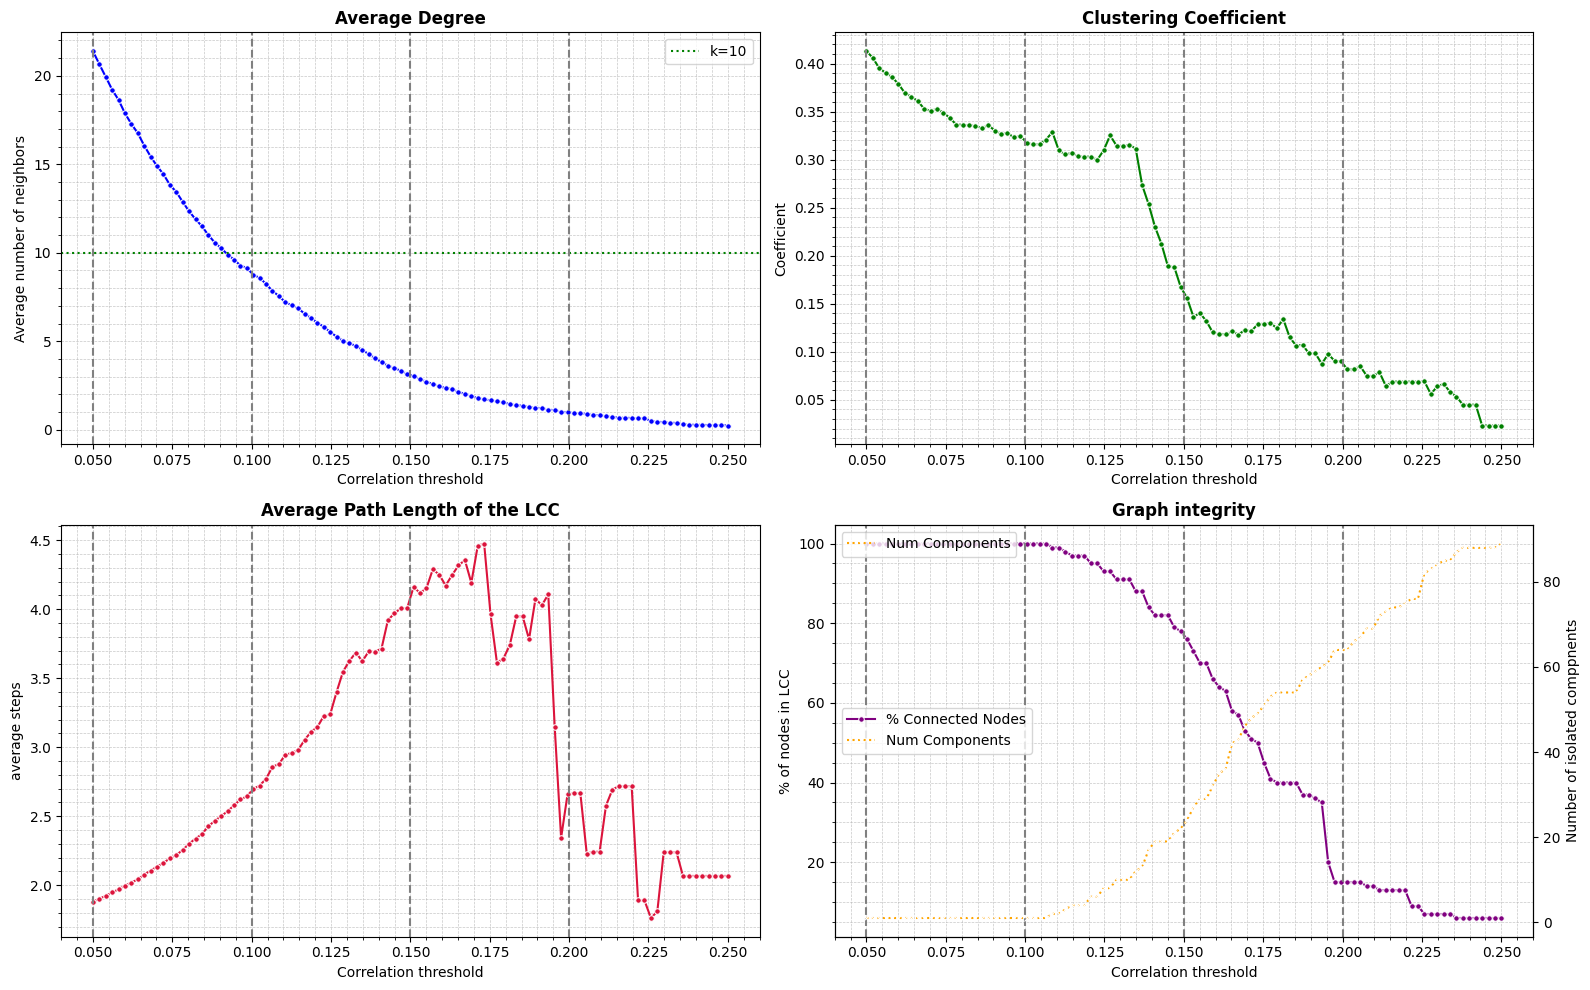

--- TARGET ZONE (degree 5 - 15) ---
    Threshold  Edges  Avg_Degree  Avg_Clustering  Avg_Path_Length  \
10     0.0702    745       14.90          0.3507           2.1339   
11     0.0722    722       14.44          0.3529           2.1614   
12     0.0742    692       13.84          0.3489           2.1939   
13     0.0763    672       13.44          0.3435           2.2182   
14     0.0783    644       12.88          0.3365           2.2552   
15     0.0803    617       12.34          0.3364           2.3002   
16     0.0823    595       11.90          0.3357           2.3374   
17     0.0843    575       11.50          0.3355           2.3697   
18     0.0864    550       11.00          0.3326           2.4269   
19     0.0884    529       10.58          0.3360           2.4657   
20     0.0904    513       10.26          0.3304           2.5002   
21     0.0924    495        9.90          0.3268           2.5356   
22     0.0944    481        9.62          0.3278           2.5784  

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


def setup_plot(ax, title, ylabel):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Correlation threshold")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.minorticks_on()


# Plot 1
sns.lineplot(data=df_res, x='Threshold', y='Avg_Degree', ax=axes[0,0], marker='o', markersize=4, color='blue')
setup_plot(axes[0,0], "Average Degree", "Average number of neighbors")
#Orizontal line for ideal target (10 neighbors)
axes[0,0].axhline(10, color='green', linestyle=':', label='k=10')
axes[0,0].axvline(0.05, color='gray', linestyle='--')
axes[0,0].axvline(0.10, color='gray', linestyle='--')
axes[0,0].axvline(0.15, color='gray', linestyle='--')
axes[0,0].axvline(0.20, color='gray', linestyle='--')
axes[0,0].legend()


# Plot 2
sns.lineplot(data=df_res, x='Threshold', y='Avg_Clustering', ax=axes[0,1], marker='o', markersize=4, color='green')
setup_plot(axes[0,1], "Clustering Coefficient", "Coefficient")
axes[0,1].axvline(0.05, color='gray', linestyle='--')
axes[0,1].axvline(0.10, color='gray', linestyle='--')
axes[0,1].axvline(0.15, color='gray', linestyle='--')
axes[0,1].axvline(0.20, color='gray', linestyle='--')


# Plot 3
sns.lineplot(data=df_res, x='Threshold', y='Avg_Path_Length', ax=axes[1,0], marker='o', markersize=4, color='crimson')
setup_plot(axes[1,0], "Average Path Length of the LCC", "average steps")
axes[1,0].axvline(0.05, color='gray', linestyle='--')
axes[1,0].axvline(0.10, color='gray', linestyle='--')
axes[1,0].axvline(0.15, color='gray', linestyle='--')
axes[1,0].axvline(0.20, color='gray', linestyle='--')


# Plot 4
ax4 = axes[1,1]
sns.lineplot(data=df_res, x='Threshold', y='Nodes_in_LCC_pct', ax=ax4, marker='o', markersize=4, color='purple', label='% Connected Nodes')
setup_plot(ax4, "Graph integrity", "% of nodes in LCC")
ax4.axvline(0.05, color='gray', linestyle='--')
ax4.axvline(0.10, color='gray', linestyle='--')
ax4.axvline(0.15, color='gray', linestyle='--')
ax4.axvline(0.20, color='gray', linestyle='--')
ax4b = ax4.twinx()
sns.lineplot(data=df_res, x='Threshold', y='Connected_Components', ax=ax4b, marker='x', markersize=4, color='orange', linestyle=':', label='Num Components')
ax4b.set_ylabel("Number of isolated comppnents")


lines, labels = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines + lines2, labels + labels2, loc='center left')


plt.tight_layout()
plt.show()


target_zone = df_res[(df_res['Avg_Degree'] < 15) & (df_res['Avg_Degree'] > 5)]
print("--- TARGET ZONE (degree 5 - 15) ---")
print(target_zone.round(4))


In [21]:
# Test Setup
k_values = [5, 10, 15]
modes = ["Directed", "Undirected"]
results = []

#i tested different combinations of k and modes
for k in k_values:
    adj_base = kneighbors_graph(
        X,
        n_neighbors=k,
        mode="connectivity",
        metric="correlation",
        include_self=False,
        n_jobs=-1,
    )  # returns a directed kNN adjacency matrix

    for mode in modes:
        if mode == "Directed":
            G = nx.from_scipy_sparse_array(adj_base, create_using=nx.DiGraph)
            components = list(nx.weakly_connected_components(G))
            avg_clustering = nx.average_clustering(G.to_undirected())
            out_degrees = np.array([d for _, d in G.out_degree()], dtype=float)
            in_degrees = np.array([d for _, d in G.in_degree()], dtype=float)
            avg_out_degree = out_degrees.mean() if len(out_degrees) else 0.0
            avg_in_degree = in_degrees.mean() if len(in_degrees) else 0.0
            avg_degree = (out_degrees + in_degrees).mean() if len(out_degrees) else 0.0
        else:
            adj_sym = adj_base.maximum(adj_base.T)
            G = nx.from_scipy_sparse_array(adj_sym, create_using=nx.Graph)
            components = list(nx.connected_components(G))
            avg_clustering = nx.average_clustering(G)
            degrees = np.array([d for _, d in G.degree()], dtype=float)
            avg_degree = degrees.mean() if len(degrees) else 0.0
            avg_out_degree = np.nan
            avg_in_degree = np.nan

        num_edges = G.number_of_edges()

        if len(components) > 0:
            largest_cc = max(components, key=len)
            nodes_in_lcc_pct = len(largest_cc) / G.number_of_nodes() * 100
            num_components = len(components)

            if len(largest_cc) > 1:
                subgraph = G.subgraph(largest_cc).to_undirected()
                avg_path_len = nx.average_shortest_path_length(subgraph)
            else:
                avg_path_len = 0.0
        else:
            nodes_in_lcc_pct = 0.0
            num_components = 0
            avg_path_len = 0.0

        results.append(
            {
                "Mode": mode,
                "K": k,
                "Edges": num_edges,
                "Avg Degree": round(float(avg_degree), 2),
                "Avg Out Degree": round(float(avg_out_degree), 2) if np.isfinite(avg_out_degree) else np.nan,
                "Avg In Degree": round(float(avg_in_degree), 2) if np.isfinite(avg_in_degree) else np.nan,
                "Clustering": round(float(avg_clustering), 4),
                "Path Len (LCC)": round(float(avg_path_len), 4),
                "% Connected": round(float(nodes_in_lcc_pct), 1),
                "Num Components": int(num_components),
            }
        )

df_results = pd.DataFrame(results)

best_row = (
    df_results[df_results["% Connected"] == 100.0]
    .sort_values(["Avg Degree"])
    .head(30)
)
print(best_row)

if not best_row.empty:
    k_best = int(best_row.iloc[0]["K"])
    deg_best = best_row.iloc[0]["Avg Degree"]
    mode_best = best_row.iloc[0]["Mode"]

    print(f"The best configuration seems to be: {mode_best} with k={k_best}")
    print(f"Reason: It guarantees 100% connectivity while keeping a low average degree ({deg_best}).")
else:
    print("No perfect configuration found (connectivity < 99%). Try increasing k.")


         Mode   K  Edges  Avg Degree  Avg Out Degree  Avg In Degree  \
1  Undirected   5    350        7.00             NaN            NaN   
0    Directed   5    500       10.00             5.0            5.0   
3  Undirected  10    638       12.76             NaN            NaN   
5  Undirected  15    891       17.82             NaN            NaN   
2    Directed  10   1000       20.00            10.0           10.0   
4    Directed  15   1500       30.00            15.0           15.0   

   Clustering  Path Len (LCC)  % Connected  Num Components  
1      0.2233          2.7960        100.0               1  
0      0.2233          2.7960        100.0               1  
3      0.3086          2.2341        100.0               1  
5      0.3518          1.9893        100.0               1  
2      0.3086          2.2341        100.0               1  
4      0.3518          1.9893        100.0               1  
The best configuration seems to be: Undirected with k=5
Reason: It guarante


 ----- GRAPH RECAP -----
Nodes: 100
Features: 793
Edges: 350
Average Degree: 7.00


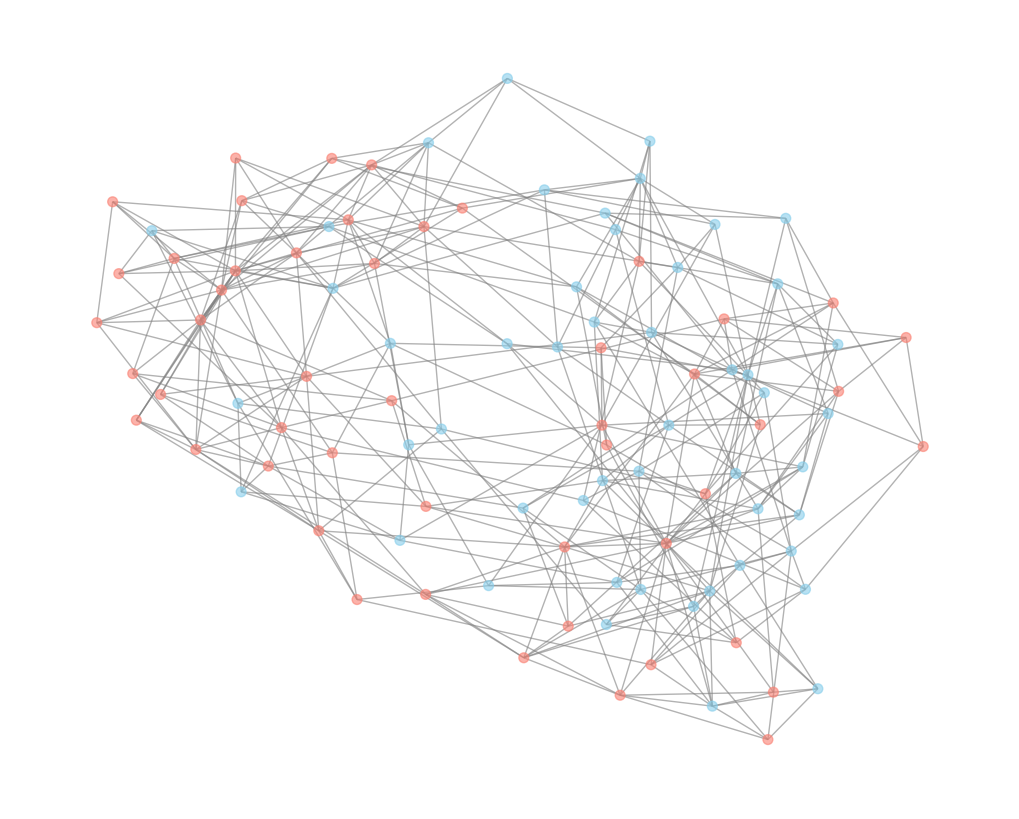

In [22]:
K_NEIGHBORS = 5

adj_matrix = kneighbors_graph(
        X,
        n_neighbors=K_NEIGHBORS,
        mode="connectivity",
        metric="correlation",
        include_self=False,
        n_jobs=-1,
    )

#Conversion to pytorch + simmetrization
adj_coo = adj_matrix.tocoo() #COO = coordinates
row = torch.from_numpy(adj_coo.row.astype(np.int64))
col = torch.from_numpy(adj_coo.col.astype(np.int64))
edge_index = torch.stack([row, col], dim=0)
edge_index = to_undirected(edge_index) 

x = torch.tensor(filtered_df.values, dtype=torch.float)
y = torch.tensor(y.values, dtype=torch.long)
data = Data(x=x, edge_index=edge_index, y=y)


print("\n ----- GRAPH RECAP -----")
print(f"Nodes: {data.num_nodes}")
print(f"Features: {data.num_features}")
num_edges_visual = data.num_edges // 2 
print(f"Edges: {num_edges_visual}") 
print(f"Average Degree: {data.num_edges / data.num_nodes:.2f}") 


G_check = to_networkx(data, to_undirected=True)
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_check, seed=42)
node_colors = ['skyblue' if label == 0 else 'salmon' for label in y]
nx.draw(G_check, pos, node_size=50, node_color=node_colors, edge_color='gray', alpha=0.6, with_labels=False)
plt.show()

In [23]:
h_edge = homophily(data.edge_index, data.y, method='edge')

label_counts = data.y.bincount()
probs = label_counts / label_counts.sum()
baseline_random = (probs ** 2).sum().item()

print(f"Edge: {h_edge:.4f}")
print(f"Baseline Random: {baseline_random:.4f}")
print(f"Adjusted Signal: {h_edge - baseline_random:.4f}")

Edge: 0.6429
Baseline Random: 0.5000
Adjusted Signal: 0.1429


In [24]:
local_homophily = torch.zeros(data.num_nodes)

for i in range(data.num_nodes):
    neighbors = data.edge_index[1, data.edge_index[0] == i]
        
    if neighbors.numel() > 0:
        same_label = (y[neighbors] == y[i]).sum().item()
        local_homophily[i] = same_label / neighbors.numel()
    else:
        local_homophily[i] = float('nan') 
            

bad_nodes = local_homophily[local_homophily < 0.5]
print(f"Nodes with local homophily < 0.5: {len(bad_nodes)} ")

#nodes where the majority of neighbors has a different label

Nodes with local homophily < 0.5: 21 


<h1 align="center">4. Models Instantiation and Training</h1>

In [ ]:
df = pd.read_csv("dataset/dataset_LUMINAL_A_B.csv")

target_col = "l"
df[target_col] = df[target_col].astype(str).str.strip()
df[target_col] = df[target_col].map({"Luminal B": 0, "Luminal A": 1})

y = df[target_col].copy()
numeric_df = df.drop(columns=[target_col]).copy()
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")



p = 0.05
min_n = int(np.ceil(p * numeric_df.shape[0]))

df_log = np.log2(numeric_df + 1)
mask = df_log.gt(0).sum(axis=0) >= min_n
filtered_df = df_log.loc[:, mask].copy()

X = filtered_df.copy()
X = (X - X.mean(axis=0)) / X.std(axis=0).replace(0, 1)

K_NEIGHBORS = 5
adj_matrix = kneighbors_graph(
    X, 
    n_neighbors=K_NEIGHBORS, 
    mode="connectivity", 
    metric="correlation", 
    include_self=False, 
    n_jobs=-1,
)  

adj_coo = adj_matrix.tocoo()
row = torch.from_numpy(adj_coo.row.astype(np.int64))
col = torch.from_numpy(adj_coo.col.astype(np.int64))
edge_index = torch.stack([row, col], dim=0)
edge_index = to_undirected(edge_index)

x = torch.tensor(X.values, dtype=torch.float)
y_t = torch.tensor(y.values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y_t)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)  
folds = list(rskf.split(range(data.num_nodes), data.y.cpu())) 
# 100 total iterations. the folds are pre generated so i can test different models in multiple steps.

<h2 align="center">4.1 Baseline Configuration and Metrics</h2>

In [26]:
INPUT_DIM = data.x.shape[1]

MODEL_CONFIGS = {
    #1. MLP (Baseline)
    "mlp": {
        "cls": MLP,
        "kwargs": {"input_dim": INPUT_DIM}
    },

    #2. GCN - Linear, No Contrastive
    "gnn_gcn": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GCN", 
            "classifier_type": "linear",
            "contrastive": False
        }
    },

    #3. GCN - Linear, Contrastive
    "gnn_gcn_con": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GCN", 
            "classifier_type": "linear", 
            "contrastive": True,    
            "center_lr": 0.05,      
            "alpha": 0.7            
        }
    },

    # 4. GCN - MLP, No Contrastive
    "gnn_gcn_mlp": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GCN", 
            "classifier_type": "mlp",
            "contrastive": False
        }
    },

    # 5. GCN - MLP, Contrastive
    "gnn_gcn_con_mlp": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GCN", 
            "classifier_type": "mlp", 
            "contrastive": True,
            "center_lr": 0.05,
            "alpha": 0.7
        }
    }
}

In [27]:
set_seed()
device = "cpu"
validation_percentage = 0.1
learning_rate = 0.001

RESULTS = defaultdict(lambda: {'accs': [], 'sils': []})

for fold_idx, (train_idx, test_idx) in enumerate(folds):  
    
    # Split train_idx in train_inner + val_inner
    train_inner_idx, val_idx = train_test_split(
        train_idx,
        test_size=validation_percentage, 
        stratify=data.y[train_idx].cpu(), 
        random_state=42 + fold_idx
    )
    
    #this computes the various masks given the indexes calculated
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    val_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    test_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    train_mask[train_inner_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    
    for model_name, config in MODEL_CONFIGS.items():

        #this instatiates the correct model and trains it collecting all the metrics for this specific fold
        model = config["cls"](**config["kwargs"]).to(device)
        fold_acc, fold_sil = utils.train_model_one_fold(model, data, train_mask, val_mask, test_mask, lr=learning_rate)
        RESULTS[model_name]['accs'].append(fold_acc)
        RESULTS[model_name]['sils'].append(fold_sil)

    if (fold_idx + 1) % 10 == 0:
        print(f"Fold {fold_idx + 1}/{len(folds)} completed.")

Seed set at 42.
Fold 10/100 completed.
Fold 20/100 completed.
Fold 30/100 completed.
Fold 40/100 completed.
Fold 50/100 completed.
Fold 60/100 completed.
Fold 70/100 completed.
Fold 80/100 completed.
Fold 90/100 completed.
Fold 100/100 completed.


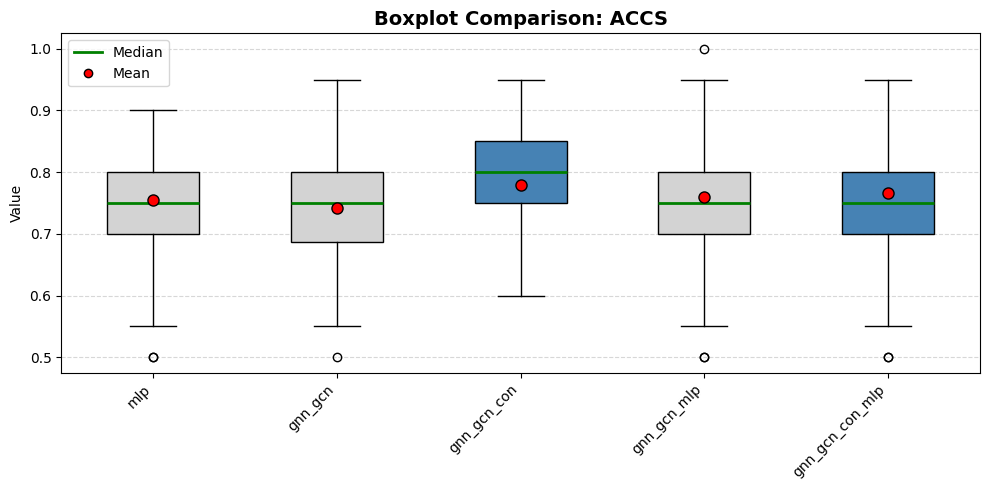

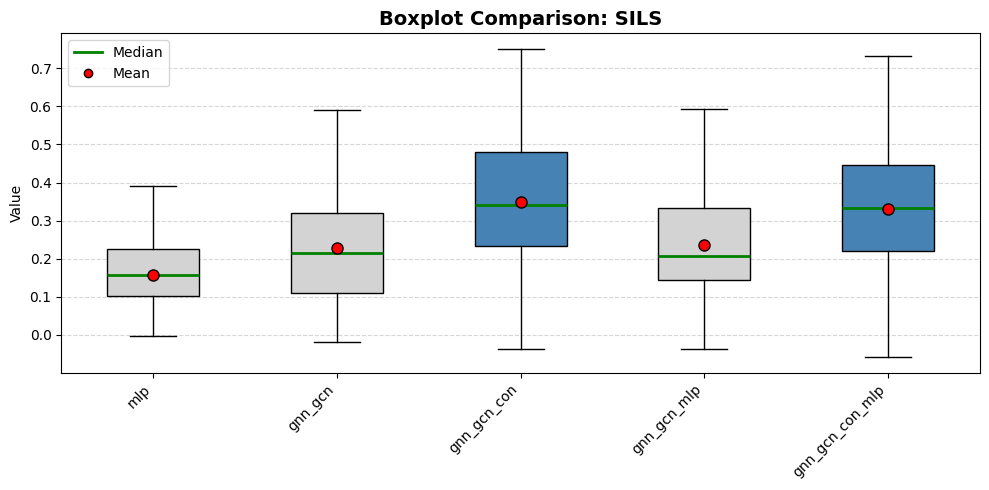

In [28]:
utils.plot_analysis(RESULTS, metric_key='accs')
utils.plot_analysis(RESULTS, metric_key='sils')

In [29]:
header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['accs'])
    print(f"{model_name:<20} | {'ACC':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(RESULTS[m1]['accs'])
    s2 = np.array(RESULTS[m2]['accs'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | ACC    | 0.7500   | 0.7555   | 0.0867   | ±0.0877
gnn_gcn              | ACC    | 0.7500   | 0.7420   | 0.0968   | ±0.0980
gnn_gcn_con          | ACC    | 0.8000   | 0.7790   | 0.0856   | ±0.0866
gnn_gcn_mlp          | ACC    | 0.7500   | 0.7600   | 0.0969   | ±0.0981
gnn_gcn_con_mlp      | ACC    | 0.7500   | 0.7660   | 0.0899   | ±0.0909
-------------------------------------------------------------------------

STATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)
Model A              vs Model B              | P-Value   
---------------------------------------------------------
No significant differences detected.


In [30]:
raw_x = data.x.cpu().numpy()
raw_y = data.y.cpu().numpy()

# Check if we can calculate silhouette (needs >1 class and >1 sample)
if len(np.unique(raw_y)) > 1:
    raw_sil = silhouette_score(raw_x, raw_y,metric="cosine")
    print(f"{'RAW DATA (Baseline)':<20} | SIL    | N/A      | {raw_sil:.4f}   | N/A      | N/A")
else:
    print("Cannot calculate Raw Silhouette (only 1 class present).")

print("-" * 75)


header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['sils'])
    print(f"{model_name:<20} | {'SIL':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Silhouette, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(RESULTS[m1]['sils'])
    s2 = np.array(RESULTS[m2]['sils'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

RAW DATA (Baseline)  | SIL    | N/A      | 0.0283   | N/A      | N/A
---------------------------------------------------------------------------
MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | SIL    | 0.1572   | 0.1573   | 0.0885   | ±0.0896
gnn_gcn              | SIL    | 0.2143   | 0.2273   | 0.1503   | ±0.1520
gnn_gcn_con          | SIL    | 0.3417   | 0.3496   | 0.1736   | ±0.1757
gnn_gcn_mlp          | SIL    | 0.2066   | 0.2352   | 0.1452   | ±0.1469
gnn_gcn_con_mlp      | SIL    | 0.3345   | 0.3298   | 0.1697   | ±0.1717
-------------------------------------------------------------------------

STATISTICALLY SIGNIFICANT PAIRS (Silhouette, p < 0.05)
Model A              vs Model B              | P-Value   
---------------------------------------------------------
mlp                  vs gnn_gcn_con          | 0.008408
mlp                  vs gnn_gcn_con_mlp 

<h2 align="center">4.2 GAT Configuration and Metrics</h2>

In [31]:
INPUT_DIM = data.x.shape[1]

GAT_MODEL_CONFIGS = {

    #1. GAT - Linear, No Contrastive
    "gnn_gat": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GAT", 
            "classifier_type": "linear",
            "contrastive": False
        }
    },

    #2. GAT - Linear, Contrastive
    "gnn_gat_con": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GAT", 
            "classifier_type": "linear", 
            "contrastive": True,    
            "center_lr": 0.05,      
            "alpha": 0.7            
        }
    },

    # 4. GAT - MLP, No Contrastive
    "gnn_gat_mlp": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GAT", 
            "classifier_type": "mlp",
            "contrastive": False
        }
    },

    # 5. GAT - MLP, Contrastive
    "gnn_gat_con_mlp": {
        "cls": GNN,
        "kwargs": {
            "input_dim": INPUT_DIM, 
            "type_layers": "GAT", 
            "classifier_type": "mlp", 
            "contrastive": True,
            "center_lr": 0.05,
            "alpha": 0.7
        }
    }
}

In [32]:
set_seed()
device = "cpu"
validation_percentage = 0.1
learning_rate = 0.001
#NO NEED TO RECREATE FOLDS

GAT_RESULTS = defaultdict(lambda: {'accs': [], 'sils': []})
GAT_RESULTS['mlp'] = copy.deepcopy(RESULTS['mlp'])

for fold_idx, (train_idx, test_idx) in enumerate(folds):  
    
    train_inner_idx, val_idx = train_test_split(
        train_idx,
        test_size=validation_percentage, 
        stratify=data.y[train_idx].cpu(), 
        random_state=42 + fold_idx
    )
    
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    val_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    test_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    
    train_mask[train_inner_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    
    for model_name, config in GAT_MODEL_CONFIGS.items():
        
        model = config["cls"](**config["kwargs"]).to(device)

        fold_acc, fold_sil = utils.train_model_one_fold(model, data, train_mask, val_mask, test_mask,lr=learning_rate)
        GAT_RESULTS[model_name]['accs'].append(fold_acc)
        GAT_RESULTS[model_name]['sils'].append(fold_sil)

    if (fold_idx + 1) % 10 == 0:
        print(f"Fold {fold_idx + 1}/{len(folds)} completed.")


Seed set at 42.
Fold 10/100 completed.
Fold 20/100 completed.
Fold 30/100 completed.
Fold 40/100 completed.
Fold 50/100 completed.
Fold 60/100 completed.
Fold 70/100 completed.
Fold 80/100 completed.
Fold 90/100 completed.
Fold 100/100 completed.


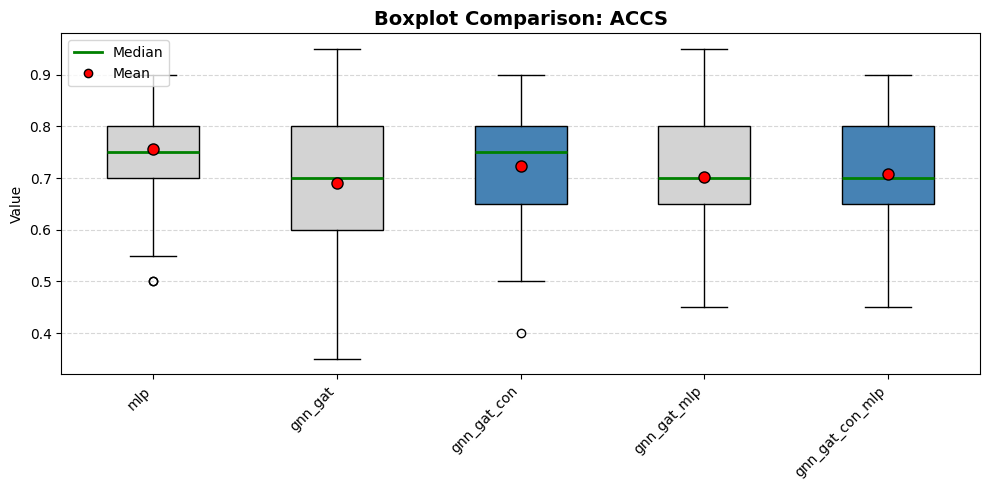

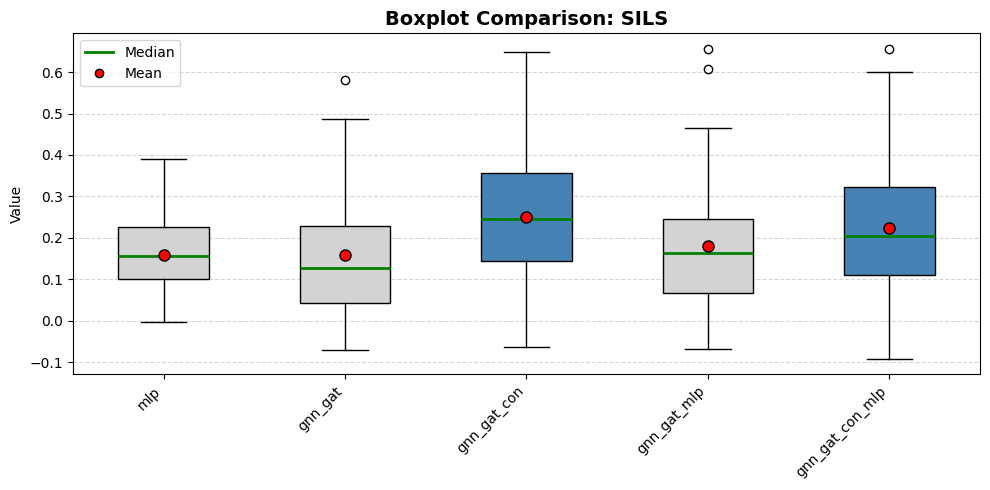

In [33]:
utils.plot_analysis(GAT_RESULTS, metric_key='accs')
utils.plot_analysis(GAT_RESULTS, metric_key='sils')

In [34]:
header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in GAT_RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['accs'])
    print(f"{model_name:<20} | {'ACC':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(GAT_RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(GAT_RESULTS[m1]['accs'])
    s2 = np.array(GAT_RESULTS[m2]['accs'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | ACC    | 0.7500   | 0.7555   | 0.0867   | ±0.0877
gnn_gat              | ACC    | 0.7000   | 0.6910   | 0.1129   | ±0.1142
gnn_gat_con          | ACC    | 0.7500   | 0.7225   | 0.1018   | ±0.1030
gnn_gat_mlp          | ACC    | 0.7000   | 0.7025   | 0.1031   | ±0.1043
gnn_gat_con_mlp      | ACC    | 0.7000   | 0.7080   | 0.0992   | ±0.1003
-------------------------------------------------------------------------

STATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)
Model A              vs Model B              | P-Value   
---------------------------------------------------------
No significant differences detected.


In [35]:
raw_x = data.x.cpu().numpy()
raw_y = data.y.cpu().numpy()

# Check if we can calculate silhouette (needs >1 class and >1 sample)
if len(np.unique(raw_y)) > 1:
    raw_sil = silhouette_score(raw_x, raw_y,metric="cosine")
    print(f"{'RAW DATA (Baseline)':<20} | SIL    | N/A      | {raw_sil:.4f}   | N/A      | N/A")
else:
    print("Cannot calculate Raw Silhouette (only 1 class present).")

print("-" * 75)


header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in GAT_RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['sils'])
    print(f"{model_name:<20} | {'SIL':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Silhouette, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(GAT_RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(GAT_RESULTS[m1]['sils'])
    s2 = np.array(GAT_RESULTS[m2]['sils'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

RAW DATA (Baseline)  | SIL    | N/A      | 0.0283   | N/A      | N/A
---------------------------------------------------------------------------
MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | SIL    | 0.1572   | 0.1573   | 0.0885   | ±0.0896
gnn_gat              | SIL    | 0.1279   | 0.1577   | 0.1371   | ±0.1387
gnn_gat_con          | SIL    | 0.2446   | 0.2512   | 0.1620   | ±0.1639
gnn_gat_mlp          | SIL    | 0.1644   | 0.1813   | 0.1489   | ±0.1507
gnn_gat_con_mlp      | SIL    | 0.2042   | 0.2239   | 0.1587   | ±0.1606
-------------------------------------------------------------------------

STATISTICALLY SIGNIFICANT PAIRS (Silhouette, p < 0.05)
Model A              vs Model B              | P-Value   
---------------------------------------------------------
No significant differences detected.


<h2 align="center">4.3 Noise Reduction</h2>

In [36]:
class ProjectedGNN(nn.Module):
    def __init__(self, gnn_class, gnn_kwargs, input_dim, project_dim=16, dropout=0.2):
        super().__init__()
        
        self.projection_block = nn.Sequential(
            nn.Linear(input_dim, project_dim),
            nn.LayerNorm(project_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        gnn_kwargs_copy = gnn_kwargs.copy()
        gnn_kwargs_copy['input_dim'] = project_dim 
        
        self.gnn = gnn_class(**gnn_kwargs_copy)

    def forward(self, x, edge_index):

        x_proj = self.projection_block(x)
        return self.gnn(x_proj, edge_index)

    def compute_loss(self, out, z, y, mask):
        return self.gnn.compute_loss(out, z, y, mask)

    def get_optimizer_params(self, base_lr):
        gnn_params = self.gnn.get_optimizer_params(base_lr)
        
        projection_params = {
            'params': self.projection_block.parameters(), 
            'lr': base_lr
        }
        
        return gnn_params + [projection_params]
#this class incapsulates a GNN and adds a compression of the input before going into the normal GNN layers

In [37]:
INPUT_DIM = data.x.shape[1]

PROJ_CONFIG = {

    # 1. GCN - Linear, No Contrastive
    "gnn_gcn_proj": {
        "cls": ProjectedGNN,
        "kwargs": {
            "gnn_class": GNN,
            "input_dim": INPUT_DIM,
            "gnn_kwargs": {
                "type_layers": "GCN",
                "classifier_type": "linear",
                "contrastive": False,
            }
        }
    },

    # 2. GCN - Linear, Contrastive
    "gnn_gcn_con_proj": {
        "cls": ProjectedGNN,
        "kwargs": {
            "gnn_class": GNN,
            "input_dim": INPUT_DIM,
            "gnn_kwargs": {
                "type_layers": "GCN",
                "classifier_type": "linear",
                "contrastive": True,
                "center_lr": 0.05,
                "alpha": 0.7,
            }
        }
    },

    # 3. GAT - Linear, No Contrastive
    "gnn_gat_proj": {
        "cls": ProjectedGNN,
        "kwargs": {
            "gnn_class": GNN,
            "input_dim": INPUT_DIM,
            "gnn_kwargs": {
                "type_layers": "GAT",
                "classifier_type": "linear",
                "contrastive": False,
            }
        }
    },
    
    # 4. GAT - Linear, Contrastive
    "gnn_gat_con_proj": {
        "cls": ProjectedGNN,
        "kwargs": {
            "gnn_class": GNN,
            "input_dim": INPUT_DIM,
            "gnn_kwargs": {
                "type_layers": "GAT",
                "classifier_type": "linear",
                "contrastive": True,
                "center_lr": 0.05,
                "alpha": 0.7,
            }
        }
    }
}

In [38]:
set_seed()

validation_percentage = 0.1
learning_rate = 0.001

PROJ_RESULTS = defaultdict(lambda: {'accs': [], 'sils': []})

for fold_idx, (train_idx, test_idx) in enumerate(folds):
    
    train_inner_idx, val_idx = train_test_split(
        train_idx,
        test_size=validation_percentage, 
        stratify=data.y[train_idx].cpu(), 
        random_state=42 + fold_idx
    )
    
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    val_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    test_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
    
    train_mask[train_inner_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    

    for model_name, config in PROJ_CONFIG.items():
        
        model = config["cls"](**config["kwargs"]).to(device)

        fold_acc, fold_sil = utils.train_model_one_fold(
            model=model, 
            data=data, 
            train_mask=train_mask, 
            val_mask=val_mask, 
            test_mask=test_mask, 
            lr=learning_rate,
            device=device
        )
        
        PROJ_RESULTS[model_name]['accs'].append(fold_acc)
        PROJ_RESULTS[model_name]['sils'].append(fold_sil)

    if (fold_idx + 1) % 10 == 0 or (fold_idx + 1) == len(folds):
        print(f"Fold {fold_idx + 1}/{len(folds)} completed.")

Seed set at 42.
Fold 10/100 completed.
Fold 20/100 completed.
Fold 30/100 completed.
Fold 40/100 completed.
Fold 50/100 completed.
Fold 60/100 completed.
Fold 70/100 completed.
Fold 80/100 completed.
Fold 90/100 completed.
Fold 100/100 completed.


In [39]:
FINAL_RESULTS = defaultdict(lambda: {'accs': [], 'sils': []})
FINAL_RESULTS['mlp']=copy.deepcopy(RESULTS['mlp'])

FINAL_RESULTS['gnn_gcn']=copy.deepcopy(RESULTS['gnn_gcn'])
FINAL_RESULTS['gnn_gcn_proj']=copy.deepcopy(PROJ_RESULTS['gnn_gcn_proj'])

FINAL_RESULTS['gnn_gcn_con']=copy.deepcopy(RESULTS['gnn_gcn_con'])
FINAL_RESULTS['gnn_gcn_con_proj']=copy.deepcopy(PROJ_RESULTS['gnn_gcn_con_proj'])

FINAL_RESULTS['gnn_gat']=copy.deepcopy(GAT_RESULTS['gnn_gat'])
FINAL_RESULTS['gnn_gat_proj']=copy.deepcopy(PROJ_RESULTS['gnn_gat_proj'])

FINAL_RESULTS['gnn_gat_con']=copy.deepcopy(GAT_RESULTS['gnn_gat_con'])
FINAL_RESULTS['gnn_gat_con_proj']=copy.deepcopy(PROJ_RESULTS['gnn_gat_con_proj'])


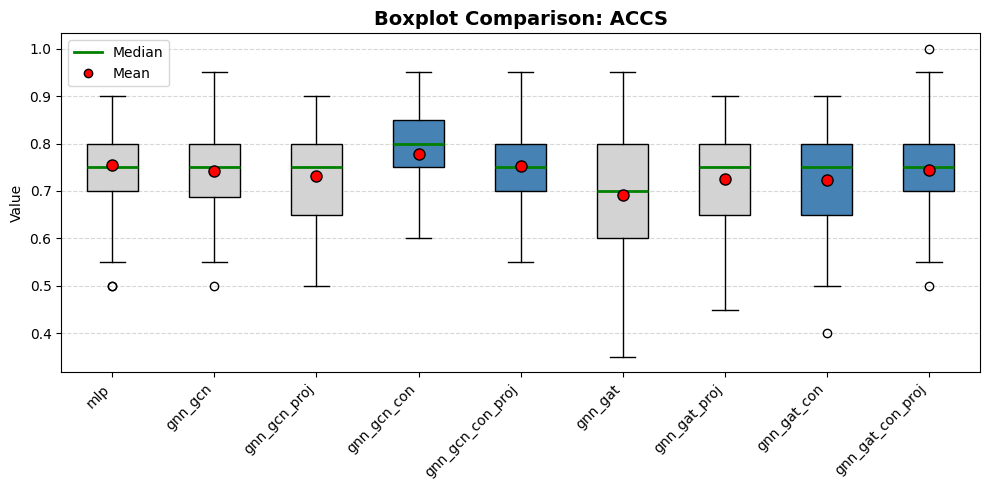

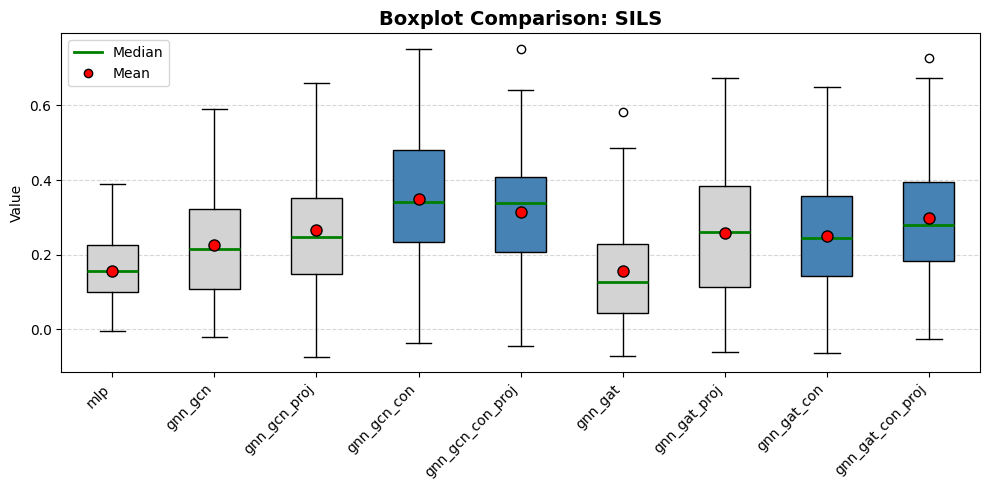

In [40]:
utils.plot_analysis(FINAL_RESULTS, metric_key='accs')
utils.plot_analysis(FINAL_RESULTS, metric_key='sils')

In [41]:
header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in FINAL_RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['accs'])
    print(f"{model_name:<20} | {'ACC':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(FINAL_RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(FINAL_RESULTS[m1]['accs'])
    s2 = np.array(FINAL_RESULTS[m2]['accs'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | ACC    | 0.7500   | 0.7555   | 0.0867   | ±0.0877
gnn_gcn              | ACC    | 0.7500   | 0.7420   | 0.0968   | ±0.0980
gnn_gcn_proj         | ACC    | 0.7500   | 0.7320   | 0.0986   | ±0.0998
gnn_gcn_con          | ACC    | 0.8000   | 0.7790   | 0.0856   | ±0.0866
gnn_gcn_con_proj     | ACC    | 0.7500   | 0.7525   | 0.0854   | ±0.0864
gnn_gat              | ACC    | 0.7000   | 0.6910   | 0.1129   | ±0.1142
gnn_gat_proj         | ACC    | 0.7500   | 0.7250   | 0.0989   | ±0.1000
gnn_gat_con          | ACC    | 0.7500   | 0.7225   | 0.1018   | ±0.1030
gnn_gat_con_proj     | ACC    | 0.7500   | 0.7445   | 0.0879   | ±0.0889
-------------------------------------------------------------------------

STATISTICALLY SIGNIFICANT PAIRS (Accuracy, p < 0.05)
Model A              vs Model B              | P-Value   
---------

In [42]:
raw_x = data.x.cpu().numpy()
raw_y = data.y.cpu().numpy()

# Check if we can calculate silhouette (needs >1 class and >1 sample)
if len(np.unique(raw_y)) > 1:
    raw_sil = silhouette_score(raw_x, raw_y,metric="cosine")
    print(f"{'RAW DATA (Baseline)':<20} | SIL    | N/A      | {raw_sil:.4f}   | N/A      | N/A")
else:
    print("Cannot calculate Raw Silhouette (only 1 class present).")

print("-" * 75)


header = f"{'MODEL':<20} | {'METRIC':<6} | {'MEDIAN':<8} | {'MEAN':<8} | {'STD':<8} | {'CI 95%':<8}"
print(header)
print("-" * len(header))

for model_name, metrics in FINAL_RESULTS.items():
    acc_med, acc_avg, acc_std, acc_ci = utils.get_stats(metrics['sils'])
    print(f"{model_name:<20} | {'SIL':<6} | {acc_med:.4f}   | {acc_avg:.4f}   | {acc_std:.4f}   | ±{acc_ci:.4f}")

print("-" * len(header))




print("\nSTATISTICALLY SIGNIFICANT PAIRS (Silhouette, p < 0.05)")
sig_header = f"{'Model A':<20} vs {'Model B':<20} | {'P-Value':<10}"
print(sig_header)
print("-" * len(sig_header))

model_names = list(FINAL_RESULTS.keys())
found_sig = False

for m1, m2 in itertools.combinations(model_names, 2):
    s1 = np.array(FINAL_RESULTS[m1]['sils'])
    s2 = np.array(FINAL_RESULTS[m2]['sils'])
    
    if len(s1) > 1 and len(s2) > 1:
        # Dependent t-test for paired samples
        _, p_val = utils.ttest_corrected(s1, s2)
        
        if p_val < 0.05:
            print(f"{m1:<20} vs {m2:<20} | {p_val:.6f}")
            found_sig = True

if not found_sig:
    print("No significant differences detected.")

RAW DATA (Baseline)  | SIL    | N/A      | 0.0283   | N/A      | N/A
---------------------------------------------------------------------------
MODEL                | METRIC | MEDIAN   | MEAN     | STD      | CI 95%  
-------------------------------------------------------------------------
mlp                  | SIL    | 0.1572   | 0.1573   | 0.0885   | ±0.0896
gnn_gcn              | SIL    | 0.2143   | 0.2273   | 0.1503   | ±0.1520
gnn_gcn_proj         | SIL    | 0.2481   | 0.2674   | 0.1686   | ±0.1706
gnn_gcn_con          | SIL    | 0.3417   | 0.3496   | 0.1736   | ±0.1757
gnn_gcn_con_proj     | SIL    | 0.3388   | 0.3146   | 0.1675   | ±0.1694
gnn_gat              | SIL    | 0.1279   | 0.1577   | 0.1371   | ±0.1387
gnn_gat_proj         | SIL    | 0.2614   | 0.2590   | 0.1729   | ±0.1749
gnn_gat_con          | SIL    | 0.2446   | 0.2512   | 0.1620   | ±0.1639
gnn_gat_con_proj     | SIL    | 0.2805   | 0.2991   | 0.1562   | ±0.1581
--------------------------------------------------